In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
df = (
    pl.scan_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet")
    .filter(pl.col("model") != "mixed-v2")
    .filter(pl.col("model") != "mixed-v3")
    .filter(pl.col("model") != "mixed-v4")  
    .filter(pl.col("model") != "mixed")
).collect(engine="streaming")
df

/tmp/ipykernel_4081421/114335648.py:7: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  ).collect(engine="streaming")


dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""GestureMidAirD2""","""mr-hydra""",300,0.7
"""PLAID""","""quant""",300,0.947858
"""ECGFiveDays""","""rdst""",400,0.997677
"""CinCECGTorso""","""rstsf""",100,0.976087
…,…,…,…
"""PigAirwayPressure""","""quant""",300,0.442308
"""ACSF1""","""mr-hydra""",500,0.9
"""BirdChicken""","""mixed-v4-ray""",300,0.9


In [3]:
from aeon.visualisation import plot_critical_difference

In [4]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,mr-hydra,quant,rdst,rstsf,mixed-v4-ray
str,f64,f64,f64,f64,f64
"""ECG5000""",0.946133,0.942978,0.944756,0.945333,0.947278
"""GestureMidAirD2""",0.7,0.678462,0.652308,0.65641,0.626923
"""PLAID""",0.941899,0.945624,0.936685,0.892458,0.955307
"""ECGFiveDays""",1.0,0.997677,0.997909,0.998374,0.997677
"""CinCECGTorso""",0.973333,0.994058,0.991884,0.974638,0.994746
…,…,…,…,…,…
"""FaceFour""",0.947727,0.975,0.988636,0.995455,0.991477
"""DodgerLoopDay""",0.581818,0.672727,0.65974,0.638961,0.625974
"""OliveOil""",0.966667,0.933333,0.883333,0.925,0.9


(<Figure size 600x240 with 1 Axes>, <Axes: >)

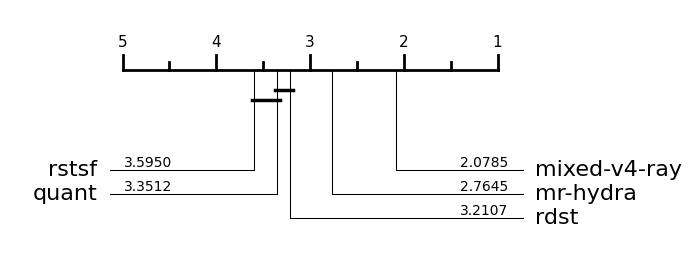

In [5]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [6]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [7]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,mr-hydra,quant,rdst,rstsf,mixed-v4-ray,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.858268,0.867717,0.848819,0.871391,0.864567,17,127,2,288
"""InsectEPGSmallTrain""",1.0,1.0,0.991968,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.9,0.81,0.95,0.9,0.95,20,20,2,512
"""BirdChicken""",0.9,0.9,0.9,0.95,0.9,20,20,2,512
…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.846154,0.840618,0.808159,0.843531,0.854312,1800,858,2,80
"""FordA""",0.951364,0.971364,0.949091,0.975152,0.988068,3601,1320,2,500
"""FordB""",0.830617,0.800741,0.821728,0.821975,0.835494,3636,810,2,500


59


(<Figure size 600x240 with 1 Axes>, <Axes: >)

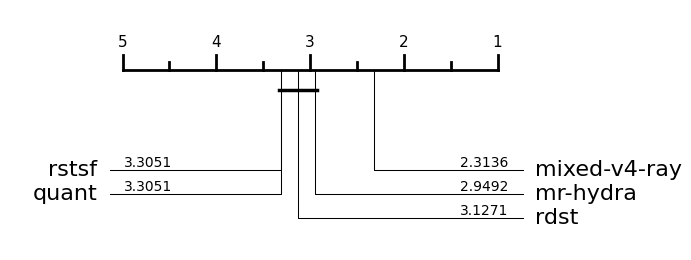

In [8]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

41


(<Figure size 600x240 with 1 Axes>, <Axes: >)

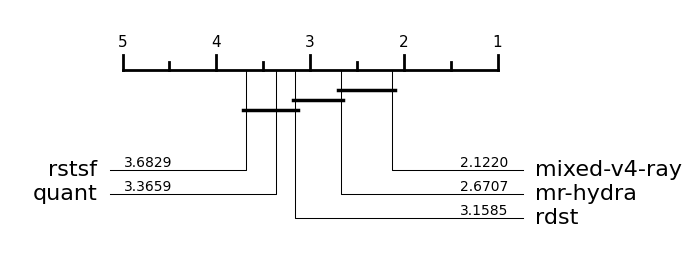

In [9]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

21


(<Figure size 600x240 with 1 Axes>, <Axes: >)

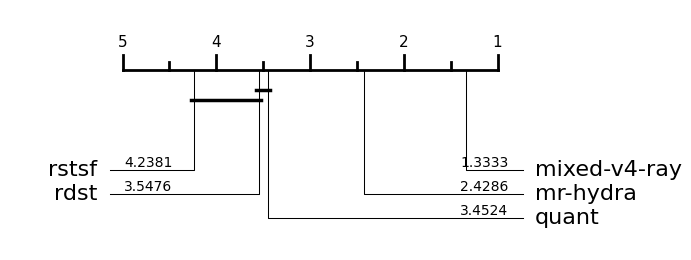

In [10]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [11]:
s_large

dataset,mr-hydra,quant,rdst,rstsf,mixed-v4-ray,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DistalPhalanxOutlineCorrect""",0.802899,0.788406,0.773188,0.793478,0.80942,600,276,2,80
"""MiddlePhalanxOutlineCorrect""",0.851546,0.848797,0.839175,0.845361,0.862543,600,291,2,80
"""ProximalPhalanxOutlineCorrect""",0.919588,0.907904,0.88488,0.910653,0.922337,600,291,2,80
"""ShapesAll""",0.927333,0.873333,0.920667,0.857917,0.9275,600,600,60,512
"""Strawberry""",0.974595,0.969189,0.976216,0.967568,0.975676,613,370,2,235
…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.846154,0.840618,0.808159,0.843531,0.854312,1800,858,2,80
"""FordA""",0.951364,0.971364,0.949091,0.975152,0.988068,3601,1320,2,500
"""FordB""",0.830617,0.800741,0.821728,0.821975,0.835494,3636,810,2,500


In [12]:
import ray
ray.shutdown()